# Intro to Network Science for Infrastructure Systems (Civil Engineering) — Examples

This notebook accompanies the lecture slides. It provides small, **offline** examples using `networkx`.

**What you'll see**
1. Road-like grid network: shortest paths, centrality, and “critical links”
2. Comparing classic network models (random / small‑world / scale‑free)
3. Robustness under random vs targeted failures
4. A simple interdependent (multilayer) toy example

> Tip: Run top-to-bottom.

In [1]:
# --- Setup ---
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

print("Python:", __import__("sys").version.split()[0])
print("NetworkX:", nx.__version__)

Python: 3.12.5
NetworkX: 3.5


## 1) A road-like grid network (spatially embedded)

A road network is often close to **planar**, geographically constrained, and has relatively narrow degree distribution.
We'll use a 10×10 grid to mimic that structure.

We'll also assign **travel time weights** (e.g., free-flow time) to edges.

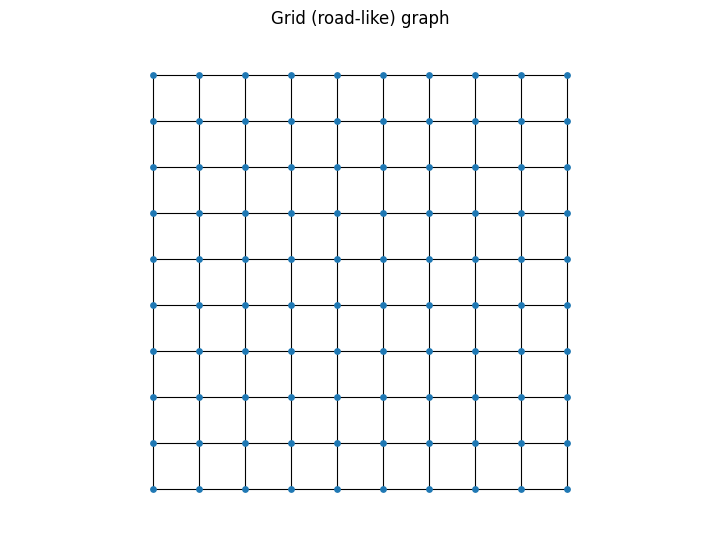

In [2]:
# Build a 10x10 grid graph and label nodes as integers
G = nx.grid_2d_graph(10, 10)
G = nx.convert_node_labels_to_integers(G)

# Add weights (travel time). We'll make some edges "slower" to mimic congestion or work zones.
rng = np.random.default_rng(7)
for u, v in G.edges():
    base = 1.0
    slow = 1.0 + 2.0 * rng.random()  # between 1 and 3
    # randomly choose some slow edges
    w = slow if rng.random() < 0.12 else base
    G.edges[u, v]["time"] = w

# Layout for plotting (grid-like)
pos = {n: (n % 10, n // 10) for n in G.nodes()}

plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=15, width=0.8)
plt.title("Grid (road-like) graph")
plt.axis("equal"); plt.axis("off")
plt.show()

### Shortest path with weights

In transport, “distance” is usually an **impedance** (travel time, generalized cost, tolls, etc.).

Origin: 0 Destination: 99
Shortest travel time: 18.0
Number of nodes on path: 19


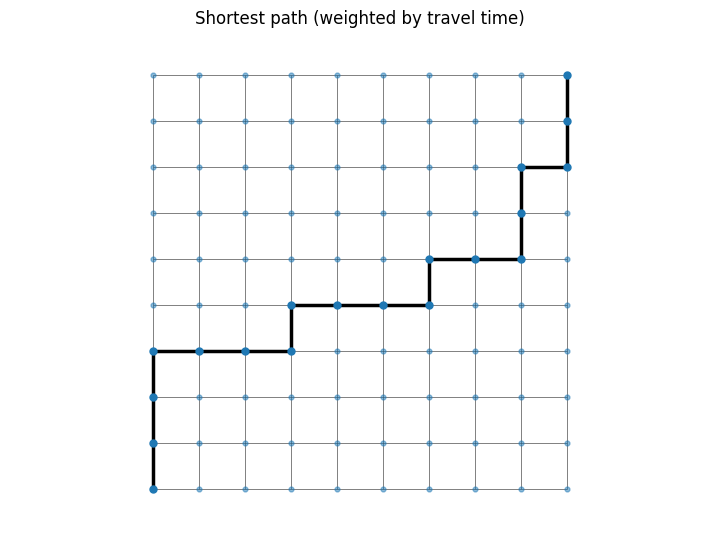

In [3]:
origin = 0
dest = 99

path = nx.shortest_path(G, source=origin, target=dest, weight="time")
path_len = nx.shortest_path_length(G, source=origin, target=dest, weight="time")

print("Origin:", origin, "Destination:", dest)
print("Shortest travel time:", round(path_len, 2))
print("Number of nodes on path:", len(path))

# Plot the path
plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=12, width=0.7, alpha=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=25)
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path[:-1], path[1:])), width=2.5)
plt.title("Shortest path (weighted by travel time)")
plt.axis("equal"); plt.axis("off")
plt.show()

### Node criticality (betweenness centrality)

Betweenness centrality ≈ how often a node lies on shortest paths between other nodes.
In civil infrastructure terms: nodes (or links) with high betweenness can be **critical corridors**, **bridges**, or **transfer points**.

In [4]:
# Betweenness can be expensive for large networks; our grid is small.
bc = nx.betweenness_centrality(G, weight="time", normalized=True)

# Show top-10 nodes by betweenness
top = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:10]
top

[(34, 0.13910544555153856),
 (35, 0.13749681533288044),
 (65, 0.13593532657300816),
 (33, 0.13258815903275062),
 (64, 0.13227484869672435),
 (36, 0.1275710447222803),
 (66, 0.12510775293331688),
 (45, 0.12384827214027778),
 (63, 0.12009039392332788),
 (44, 0.11714787442669086)]

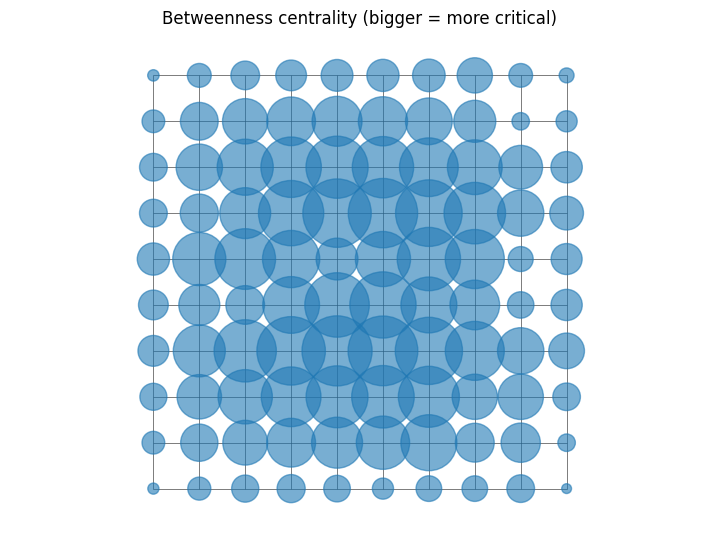

In [5]:
# Visualize betweenness as node size
sizes = np.array([bc[n] for n in G.nodes()])
sizes = 50 + 2500 * (sizes / (sizes.max() + 1e-12))

plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=sizes, width=0.6, alpha=0.6)
plt.title("Betweenness centrality (bigger = more critical)")
plt.axis("equal"); plt.axis("off")
plt.show()

## 2) Classic network models (why civil networks are “different”)

We'll compare:
- **Erdős–Rényi (ER)** random graph
- **Watts–Strogatz (WS)** small‑world
- **Barabási–Albert (BA)** scale‑free (hubs)

Then we compute basic summary metrics.

In [6]:
def summarize(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_deg = 2*m/n
    clustering = nx.average_clustering(G)
    # Average shortest path needs connected graph; use largest CC
    if nx.is_connected(G):
        apl = nx.average_shortest_path_length(G)
    else:
        C = max(nx.connected_components(G), key=len)
        apl = nx.average_shortest_path_length(G.subgraph(C))
    return dict(n=n, m=m, avg_degree=avg_deg, clustering=clustering, avg_shortest_path=apl)

n = 200
ER = nx.erdos_renyi_graph(n, 0.03, seed=1)
WS = nx.watts_strogatz_graph(n, k=6, p=0.08, seed=2)
BA = nx.barabasi_albert_graph(n, m=2, seed=3)

summaries = {
    "ER (random)": summarize(ER),
    "WS (small-world)": summarize(WS),
    "BA (scale-free)": summarize(BA),
}
summaries

{'ER (random)': {'n': 200,
  'm': 627,
  'avg_degree': 6.27,
  'clustering': 0.03125047175047175,
  'avg_shortest_path': 3.060251256281407},
 'WS (small-world)': {'n': 200,
  'm': 600,
  'avg_degree': 6.0,
  'clustering': 0.4558571428571428,
  'avg_shortest_path': 4.569145728643216},
 'BA (scale-free)': {'n': 200,
  'm': 396,
  'avg_degree': 3.96,
  'clustering': 0.08637734104486024,
  'avg_shortest_path': 3.4701005025125626}}

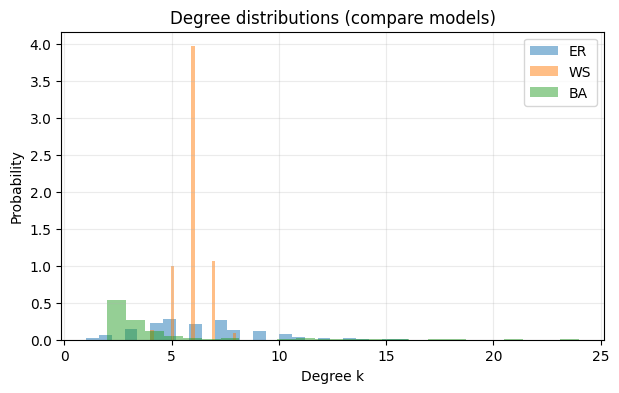

In [7]:
# Degree distributions
def degree_hist(G):
    degs = np.array([d for _, d in G.degree()])
    return degs

plt.figure(figsize=(7, 4))
for label, GG in [("ER", ER), ("WS", WS), ("BA", BA)]:
    degs = degree_hist(GG)
    plt.hist(degs, bins=25, alpha=0.5, density=True, label=label)

plt.xlabel("Degree k")
plt.ylabel("Probability")
plt.title("Degree distributions (compare models)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 3) Robustness: random vs targeted failures

Infrastructure planning often asks: *How does connectivity degrade when components fail?*

We'll measure the fraction of nodes in the **largest connected component (LCC)** as we remove nodes:
- randomly (hazard / random outages)
- targeted by highest degree (hub attack / adversarial / major facility outage)

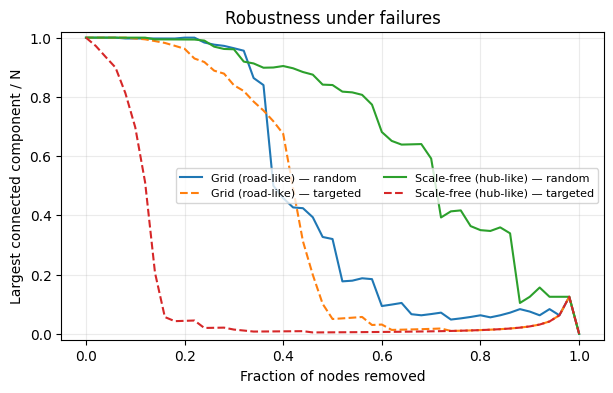

In [8]:
def largest_cc_fraction(graph):
    if graph.number_of_nodes() == 0:
        return 0.0
    C = max(nx.connected_components(graph), key=len)
    return len(C) / graph.number_of_nodes()

def simulate_removals(G0, strategy="random", steps=40, seed=0):
    rng = np.random.default_rng(seed)
    G = G0.copy()
    N0 = G.number_of_nodes()
    xs, ys = [], []
    for i in range(steps + 1):
        xs.append(i / steps)
        ys.append(largest_cc_fraction(G))
        if i == steps or G.number_of_nodes() == 0:
            break
        k = max(1, round(N0 / steps))
        if strategy == "random":
            pick = rng.choice(list(G.nodes()), size=min(k, G.number_of_nodes()), replace=False)
        elif strategy == "targeted_degree":
            pick = [u for u, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:min(k, G.number_of_nodes())]]
        else:
            raise ValueError("Unknown strategy.")
        G.remove_nodes_from(pick)
    return np.array(xs), np.array(ys)

grid = nx.convert_node_labels_to_integers(nx.grid_2d_graph(20, 20))
sf = nx.barabasi_albert_graph(400, m=2, seed=4)

plt.figure(figsize=(7, 4))
for GG, label in [(grid, "Grid (road-like)"), (sf, "Scale-free (hub-like)")]:
    x, y = simulate_removals(GG, "random", steps=50, seed=1)
    plt.plot(x, y, label=f"{label} — random")
    x, y = simulate_removals(GG, "targeted_degree", steps=50, seed=1)
    plt.plot(x, y, linestyle="--", label=f"{label} — targeted")

plt.xlabel("Fraction of nodes removed")
plt.ylabel("Largest connected component / N")
plt.title("Robustness under failures")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, ncol=2)
plt.show()

## 4) Interdependent networks (toy example)

Many civil systems are **interdependent**:
- power depends on communications & access
- transportation depends on power (signals/charging) and comms
- water depends on power (pumping)

We'll create two layers:
- a transport layer (T)
- a power layer (P)

And define dependency links T → P (“transport node requires power node”).
Then we simulate a small cascade: failing some power nodes disables dependent transport nodes.

Initial failed power nodes: [2, 21, 23, 34]
Transport nodes disabled due to dependencies: 1
Largest CC in remaining transport layer: 35 out of 36


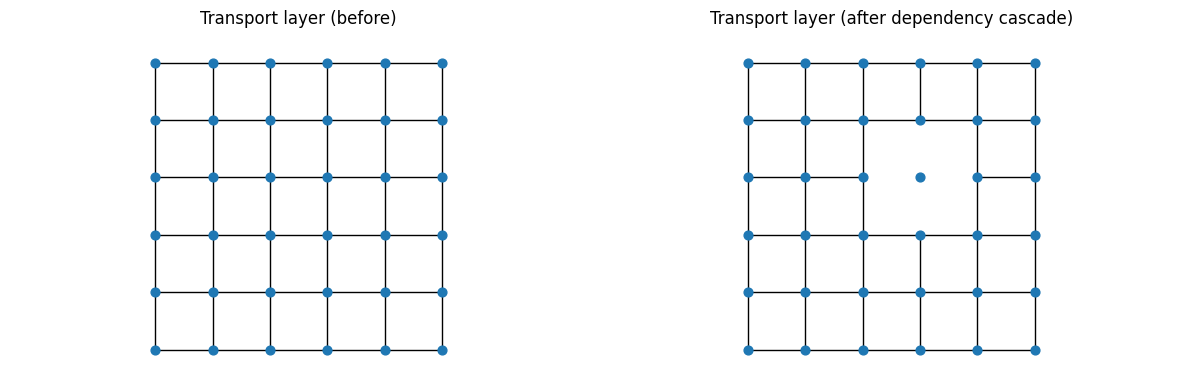

In [9]:
# Build two small graphs
T = nx.grid_2d_graph(6, 6)  # transport layer
T = nx.convert_node_labels_to_integers(T)

P = nx.erdos_renyi_graph(36, 0.06, seed=10)  # power layer
# Ensure P has same node labels 0..35 for easy mapping
P = nx.convert_node_labels_to_integers(P)

# Dependencies: each transport node depends on a (possibly nearby) power node
rng = np.random.default_rng(5)
deps = {t: int(rng.integers(0, 36)) for t in T.nodes()}  # T node -> P node

def cascade(power_failed):
    power_failed = set(power_failed)
    transport_failed = {t for t, p in deps.items() if p in power_failed}
    # Connectivity metric: size of largest CC in remaining transport graph
    T2 = T.copy()
    T2.remove_nodes_from(list(transport_failed))
    lcc = 0
    if T2.number_of_nodes() > 0:
        lcc = len(max(nx.connected_components(T2), key=len))
    return transport_failed, lcc, T2

# Fail 4 random power nodes
initial_fail = rng.choice(list(P.nodes()), size=4, replace=False)
transport_failed, lcc, T2 = cascade(initial_fail)

print("Initial failed power nodes:", sorted(initial_fail.tolist()))
print("Transport nodes disabled due to dependencies:", len(transport_failed))
print("Largest CC in remaining transport layer:", lcc, "out of", T.number_of_nodes())

# Visualize transport layer before/after
posT = {n: (n % 6, n // 6) for n in T.nodes()}

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
nx.draw(T, posT, node_size=40, width=1.0)
plt.title("Transport layer (before)")
plt.axis("equal"); plt.axis("off")

plt.subplot(1, 2, 2)
nx.draw(T2, posT, node_size=40, width=1.0)
nx.draw_networkx_nodes(T, posT, nodelist=list(transport_failed), node_size=40)
plt.title("Transport layer (after dependency cascade)")
plt.axis("equal"); plt.axis("off")

plt.tight_layout()
plt.show()

## Next steps (ideas for civil applications)

Try adapting the notebook to your own infrastructure data:
- **Roads:** edge list from GIS, weights = travel time (speed limits, congestion)
- **Transit:** GTFS stops as nodes, trips as edges, weights = headways / in-vehicle time
- **Water/power:** directed edges, capacities, pressure/flow constraints (beyond basic graphs)

**Tools you’ll likely use** (in addition to `networkx`):
- `geopandas`, `shapely`, `pyproj` for GIS
- `osmnx` for OpenStreetMap (needs internet)
- `pandana` / `igraph` for scale